In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF
from scipy import stats

from numpy.ma.core import mean, sqrt

In [2]:
#set path + read into dataframe
path = r'../rotterdam_dataset_06.xlsx'
rd = pd.read_excel(path)

#rename for easiness
rd = rd.rename(columns = {'Arrival_Date': 'arrival_date','Vessel_ID':'vessel_id','Vessel_Type':'vessel_type', 'Cargo_tons':'cargo_tons',
                         'Berth_Time_hr':'berth_time_hr'})

# + seaborn style
sns.set_theme(style = 'darkgrid')
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')

Container cargo tons ~ gamma(7.587133356127404, 0.00043871651044057096)
Tanker cargo tons ~ gamma(10.744431047610227, 0.0002497287448527972)
Bulk cargo tons ~ gamma(6.002213425528392, 0.00017839806996100744)


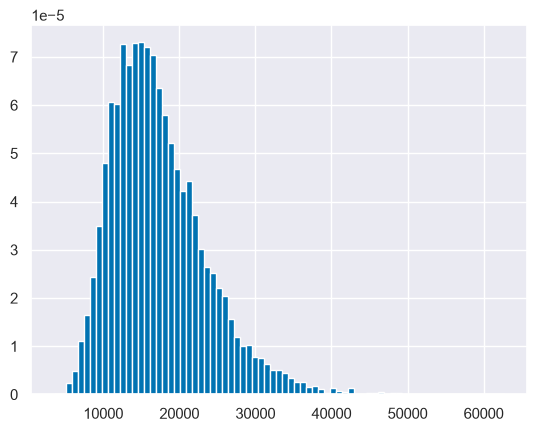

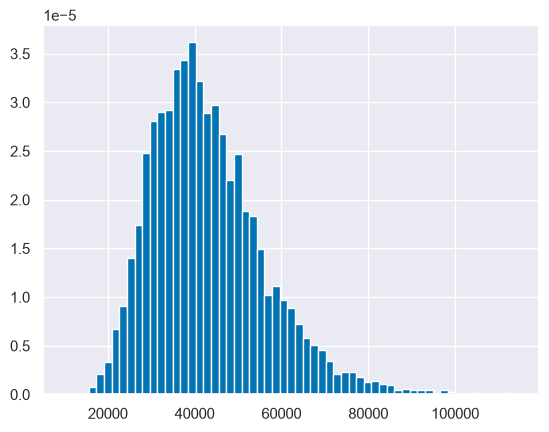

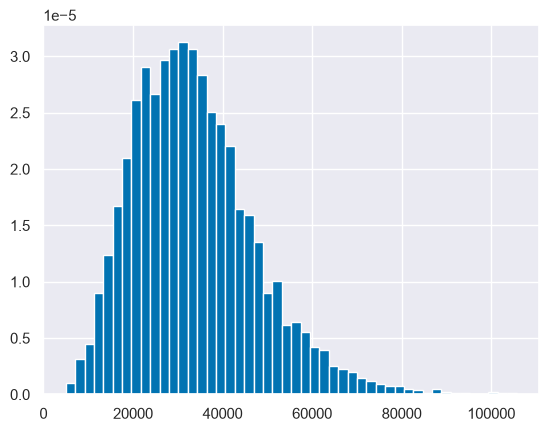

In [33]:
def cargo_mm(vessel_type: str, rd = rd):
    vessel_df = rd[rd['vessel_type'] == vessel_type]
    tons = vessel_df['cargo_tons']
    vessel_np = tons.to_numpy()
    plt.figure()
    plt.hist(vessel_np, bins = 'auto', rwidth = 10, density = True)
    m1 = mean(vessel_np)
    m2 = mean(vessel_np **2)
    estbeta = m1/(m2-m1**2)
    estalpha = m1*estbeta
    return f'{vessel_type} cargo tons ~ gamma({estalpha}, {estbeta})'

print(cargo_mm('Container'))
print(cargo_mm('Tanker'))
print(cargo_mm('Bulk'))

0        20095
1        11949
2        12465
3        38001
4        11270
         ...  
19614    42625
19615    14189
19616    14203
19617    16040
19618    23137
Name: cargo_tons, Length: 8079, dtype: int64
[20095 11949 12465 ... 14203 16040 23137]


(array([1.56638328e-07, 1.56638328e-07, 2.34957492e-06, 4.85578817e-06,
        1.11213213e-05, 1.64470244e-05, 2.44355792e-05, 3.49303471e-05,
        4.80879667e-05, 6.06190329e-05, 6.01491179e-05, 7.26801842e-05,
        6.82943110e-05, 7.28368225e-05, 7.29934608e-05, 7.20536309e-05,
        7.04872476e-05, 6.35951611e-05, 5.79561813e-05, 5.21605632e-05,
        4.66782217e-05, 4.22923485e-05, 4.41720085e-05, 3.71232837e-05,
        3.02311973e-05, 2.64718774e-05, 2.52187708e-05, 2.20860042e-05,
        2.03629826e-05, 1.56638328e-05, 1.19045129e-05, 1.00248530e-05,
        1.03381296e-05, 7.83191640e-06, 7.51863974e-06, 6.26553312e-06,
        5.16906482e-06, 5.01242649e-06, 4.54251151e-06, 3.44604321e-06,
        2.66285158e-06, 2.50621325e-06, 1.56638328e-06, 1.72302161e-06,
        1.09646830e-06, 3.13276656e-07, 1.25310662e-06, 7.83191640e-07,
        4.69914984e-07, 1.40974495e-06, 1.56638328e-07, 1.56638328e-07,
        3.13276656e-07, 3.13276656e-07, 4.69914984e-07, 1.566383

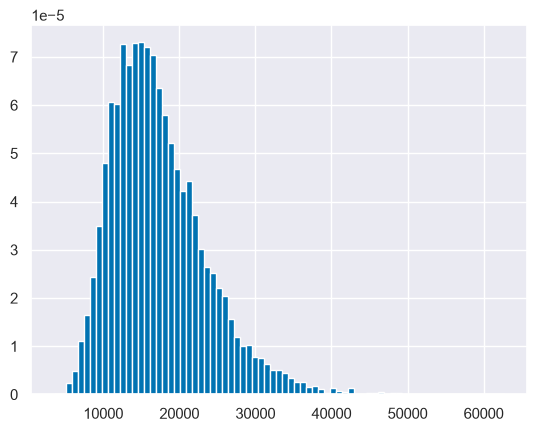

In [20]:
container = rd[rd['vessel_type'] == 'Container']
tons = container['cargo_tons']
print(tons)
container_np = tons.to_numpy()
print(container_np)
plt.figure()
plt.hist(container_np, bins = 'auto', rwidth = 10, density = True)